# 01 - Exploratory data analysis (APTOS 2019)
Evidence for rubric section 1 (problem understanding and dataset). Every figure is saved to `outputs/figures/` for the report.

In [3]:
# Run from the notebooks/ folder: move to the project root so imports and paths work
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import config
config.ensure_dirs()
config.set_seed()

## 1. Labels and class distribution

In [4]:
from src.dataset import load_labels, save_class_distribution_figure
df = load_labels()
print(f"{len(df)} labelled images")
counts = df["stage"].value_counts().sort_index()
summary = pd.DataFrame({"stage": config.CLASS_NAMES, "images": counts.values,
                        "percent": (counts.values / len(df) * 100).round(1)})
summary

3662 labelled images


,stage,images,percent
0,No DR,1805,49.3
1,Mild,370,10.1
2,Moderate,999,27.3
3,Severe,193,5.3
4,Proliferative,295,8.1


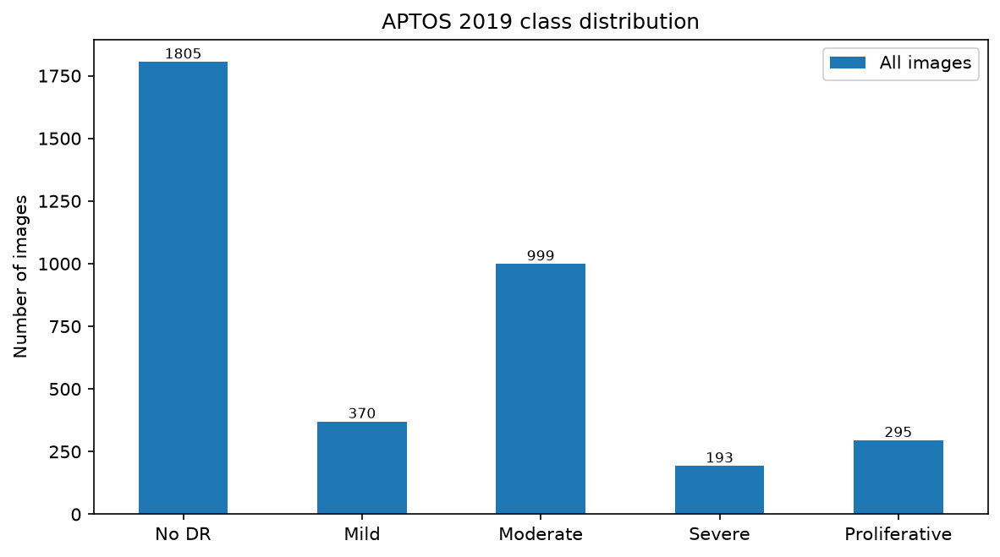

In [5]:
save_class_distribution_figure({"All images": df}, config.FIGURES_DIR / "class_distribution.png",
                               "APTOS 2019 class distribution")
Image.open(config.FIGURES_DIR / "class_distribution.png")

**Write-up note:** comment on the imbalance (No DR dominates, Mild and Severe are rare) and why accuracy alone would be misleading.

## 2. Image sizes (acquisition hardware varies)

In [6]:
sizes = []
for i in df["id_code"].sample(min(500, len(df)), random_state=config.SEED):
    with Image.open(config.RAW_IMAGE_DIR / f"{i}.png") as im:
        sizes.append(im.size)
sizes = pd.DataFrame(sizes, columns=["width", "height"])
print(sizes.describe().round(0))
print("\nMost common resolutions:\n", sizes.value_counts().head(8))

        width  height
count   500.0   500.0
mean   2037.0  1541.0
std     918.0   559.0
min     474.0   358.0
25%    1050.0  1050.0
50%    2144.0  1536.0
75%    2588.0  1958.0
max    4288.0  2848.0

Most common resolutions:
 width  height
1050   1050      140
2588   1958       74
3216   2136       70
2416   1736       69
2048   1536       41
819    614        34
3388   2588       22
1844   1226       13
Name: count, dtype: int64


**Write-up note:** different resolutions come from different fundus cameras. This links to learning outcome 2 (acquisition hardware) and justifies resizing and cropping.

## 3. Example images per stage

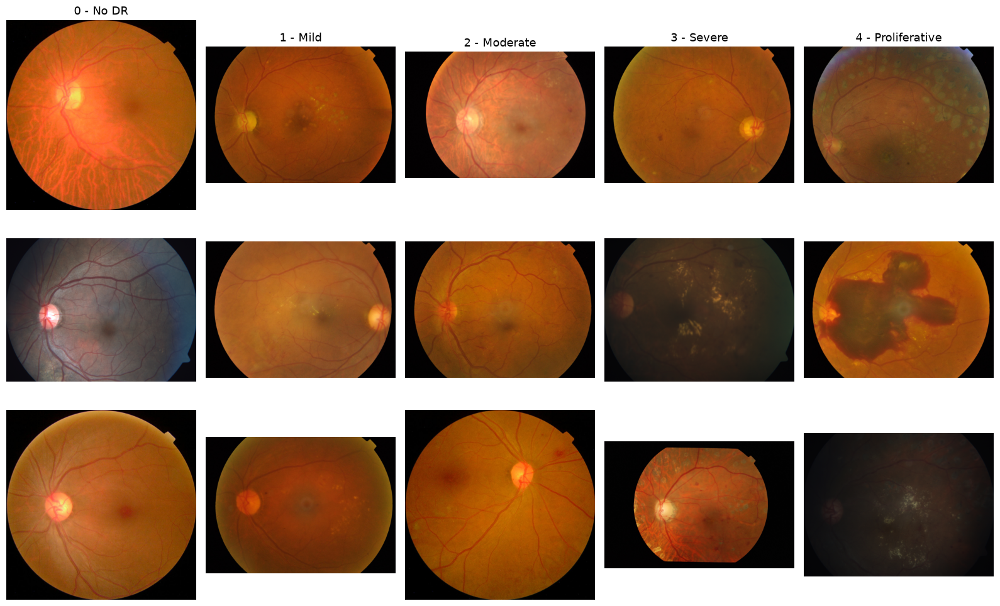

In [7]:
fig, axes = plt.subplots(3, 5, figsize=(16, 10))
for stage in range(config.NUM_CLASSES):
    ids = df[df["stage"] == stage]["id_code"].sample(3, random_state=config.SEED)
    for row, image_id in enumerate(ids):
        axes[row, stage].imshow(Image.open(config.RAW_IMAGE_DIR / f"{image_id}.png"))
        axes[row, stage].axis("off")
    axes[0, stage].set_title(f"{stage} - {config.CLASS_NAMES[stage]}", fontsize=13)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "samples_per_stage.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Duplicate check (data leakage)
Flagged pairs are shown so you can confirm they are real copies. If they are clearly different photos, lower `DUPLICATE_HASH_THRESHOLD` in `config.py`.

original_images                     3662
duplicate_groups                     220
images_in_duplicate_groups           581
conflicting_label_images_dropped     195
images_after_cleaning               3240
dtype: int64


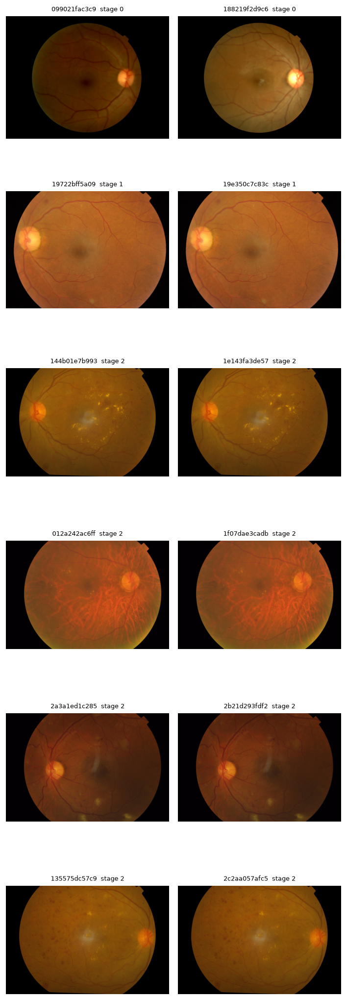

In [8]:
from src.dataset import save_duplicate_examples, remove_duplicates
clean_df, dup_report = remove_duplicates(df)
print(pd.Series(dup_report))
save_duplicate_examples(df, n=6)
Image.open(config.FIGURES_DIR / "duplicate_examples.png")

## 5. Stratified train / validation / test split

In [9]:
from src.dataset import prepare_splits, split_summary
train_df, val_df, test_df = prepare_splits(force=True)
table = split_summary(train_df, val_df, test_df)
table.to_csv(config.FIGURES_DIR / "split_table.csv")
table

Duplicate report: {'original_images': 3662, 'duplicate_groups': 220, 'images_in_duplicate_groups': 581, 'conflicting_label_images_dropped': 195, 'images_after_cleaning': 3240}


,train,val,test
No DR,1121,240,241
Mild,226,49,48
Moderate,626,134,134
Severe,113,24,24
Proliferative,182,39,39
Total,2268,486,486


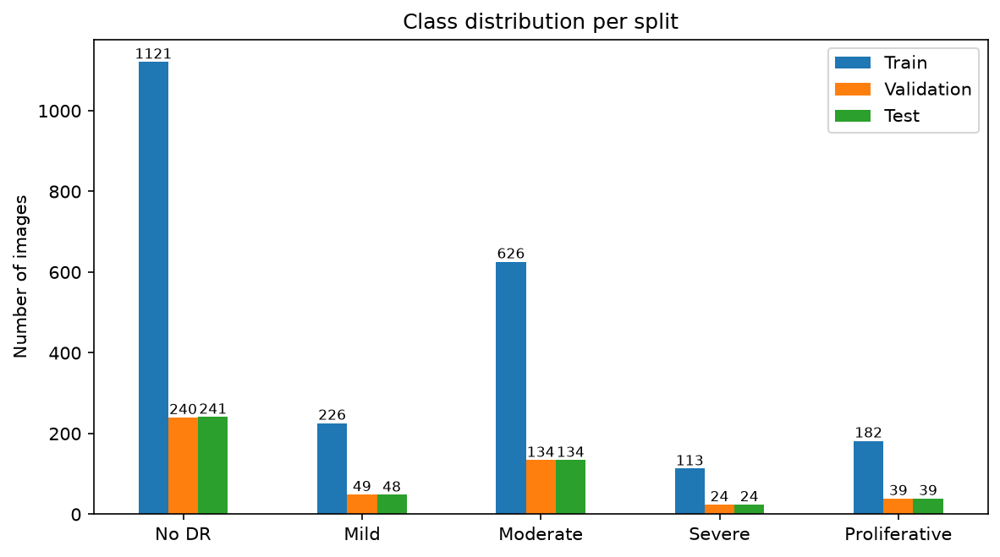

In [10]:
save_class_distribution_figure({"Train": train_df, "Validation": val_df, "Test": test_df},
                               config.FIGURES_DIR / "split_distribution.png", "Class distribution per split")
Image.open(config.FIGURES_DIR / "split_distribution.png")

## 6. Preprocessing pipeline

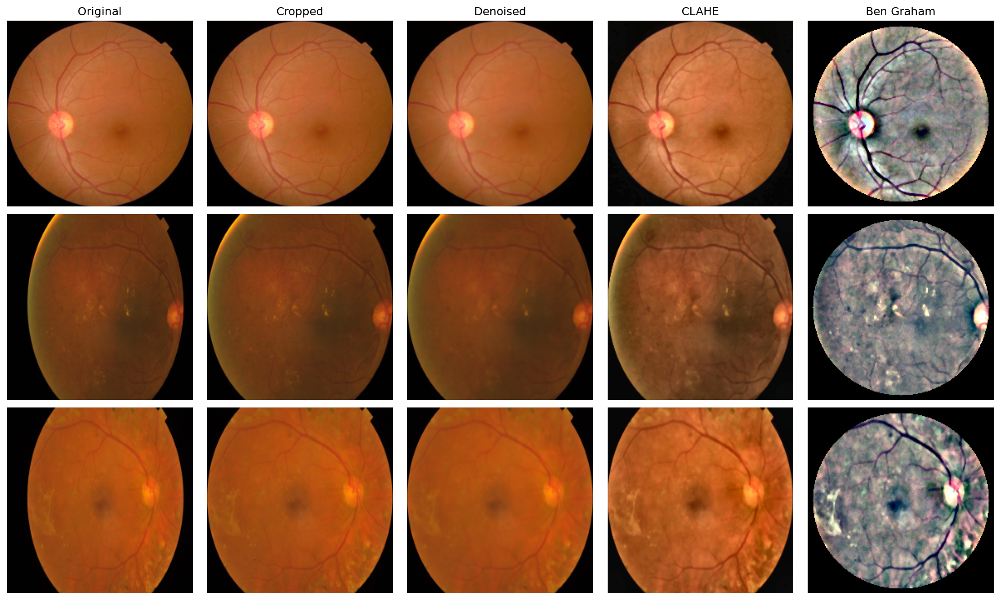

In [11]:
from src.preprocessing import save_pipeline_figure
examples = [config.RAW_IMAGE_DIR / f"{df[df['stage'] == s]['id_code'].iloc[0]}.png" for s in (0, 2, 4)]
save_pipeline_figure(examples)
Image.open(config.FIGURES_DIR / "preprocessing_pipeline.png")

## 7. Augmentation and balancing

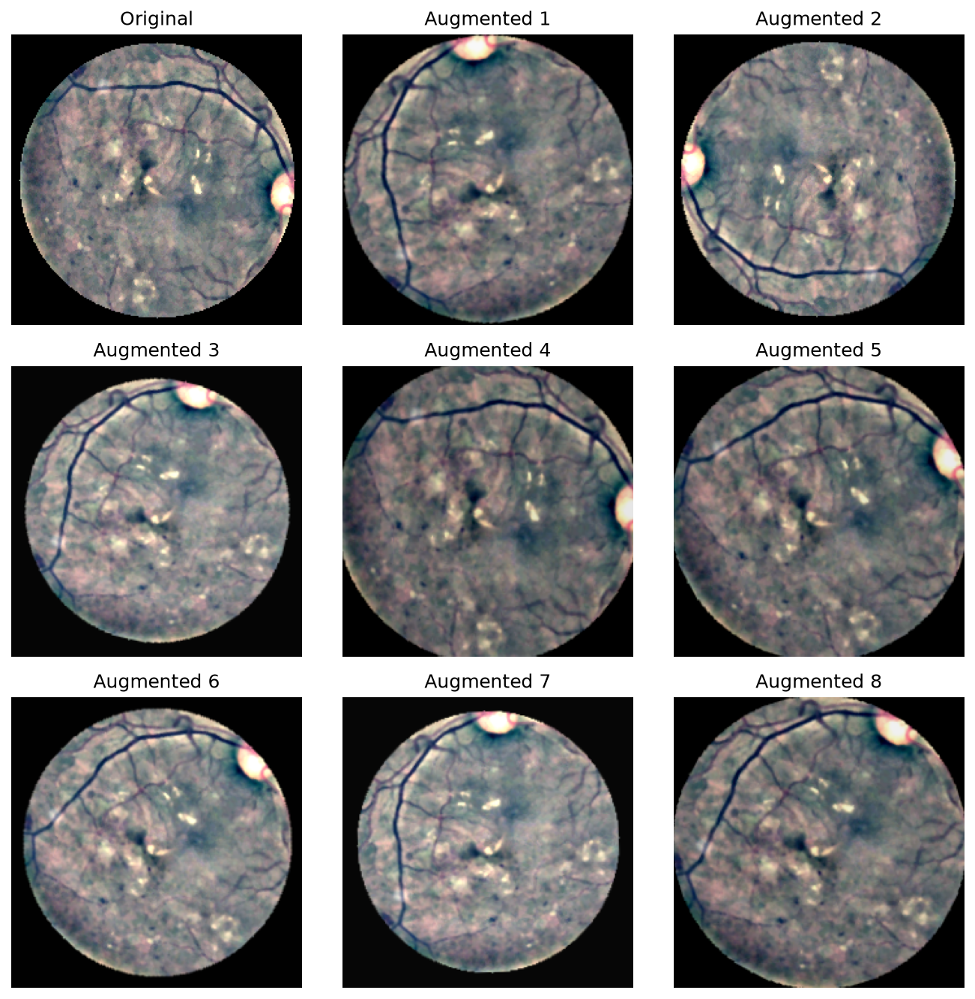

In [12]:
from src.preprocessing import load_image, preprocess_image
from src.augmentation import save_augmentation_figure
img = preprocess_image(load_image(examples[1]))
save_augmentation_figure(img, n=8)
Image.open(config.FIGURES_DIR / "augmentation_examples.png")

           stage  class_weight
0          No DR         0.405
1           Mild         2.007
2       Moderate         0.725
3         Severe         4.014
4  Proliferative         2.492


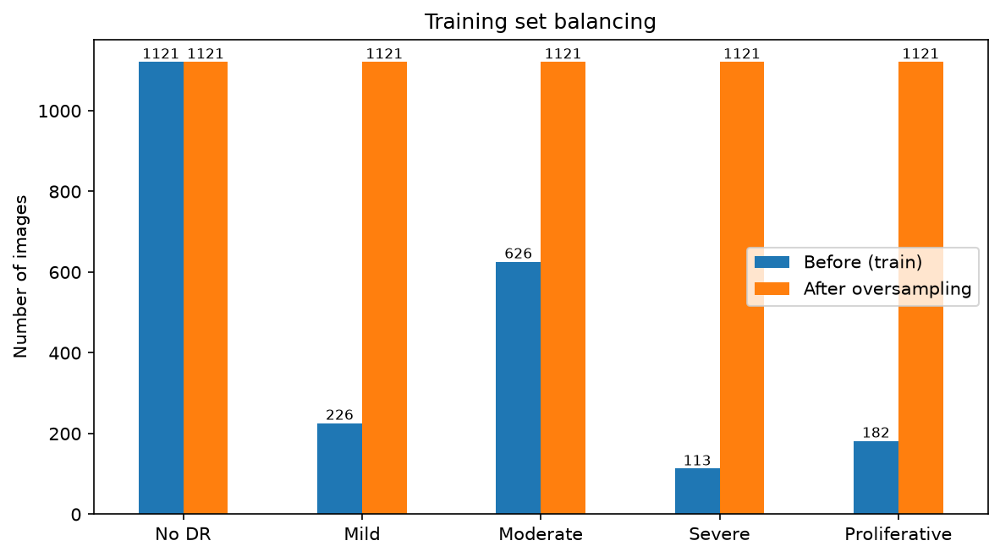

In [13]:
from src.dataset import get_class_weights, oversample
weights = get_class_weights(train_df)
print(pd.DataFrame({"stage": config.CLASS_NAMES, "class_weight": weights.round(3)}))
save_class_distribution_figure({"Before (train)": train_df, "After oversampling": oversample(train_df)},
                               config.FIGURES_DIR / "balancing_before_after.png", "Training set balancing")
Image.open(config.FIGURES_DIR / "balancing_before_after.png")